# 02 — Modelado · Separar train/test


Split elegido: **80/20 estratificado**. El 20% de test se prioriza para que la estimación final tenga suficientes ictus (~50) y sea estable. La validación cruzada, cuando llegue, subdivide el 80% de train — no crea un tercer bloque.

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("../data/raw/stroke_dataset.csv")
df.shape

(4981, 11)

## Features y target

In [3]:


X = df.drop(columns="stroke")
y = df["stroke"]



## Split estratificado 80/20

- `test_size=0.20`: 20% al test.
- `stratify=y`: fuerza la proporción de ictus (~5%) en **ambos** lados. 
- `random_state=42`: fija el sorteo → mismo split en cada corrida (reproducible).

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42,
)

## Chequeo de estratificación

In [5]:
resumen = pd.DataFrame(
    {
        "n_filas": [len(y), len(y_train), len(y_test)],
        "n_ictus": [int(y.sum()), int(y_train.sum()), int(y_test.sum())],
        "prop_ictus": [y.mean(), y_train.mean(), y_test.mean()],
    },
    index=["original", "train", "test"],
)
resumen

,n_filas,n_ictus,prop_ictus
original,4981,248,0.049789
train,3984,198,0.049699
test,997,50,0.050150


## Aplicar drops (variables descartadas en el EDA)

Cuatro categóricas se descartaron por planas (`gender`, `Residence_type`) o proxy de edad (`ever_married`, `work_type`).

In [6]:
descartar = ["gender", "Residence_type", "ever_married", "work_type"]

X_train = X_train.drop(columns=descartar)
X_test  = X_test.drop(columns=descartar)

print(X_train.columns.tolist())

['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi', 'smoking_status']


## Codificar smoking_status (one-hot)

Única categórica que sobrevive el drop (`gender`, `Residence_type`, `ever_married`, `work_type` se descartaron por planas o proxy de edad). Es **nominal** (sin orden) → one-hot, no ordinal.

`Unknown` va como categoría de **referencia** (todo-ceros, `drop="Unknown"`): los niveles informativos conservan su peso propio y una fila `Unknown` no aporta señal de tabaquismo — el modelo se apoya en el resto. Decisión conservadora para una herramienta de riesgo desplegable, donde un `Unknown` futuro puede corresponder a un niño pequeño.



In [7]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    categories=[["never smoked", "smokes", "formerly smoked", "Unknown"]],
    drop=["Unknown"],
    sparse_output=False,
    handle_unknown="error",
)

smk_train = encoder.fit_transform(X_train[["smoking_status"]])
smk_test  = encoder.transform(X_test[["smoking_status"]])

## Chequeo — one-hot de smoking_status

Confirmar con la salida real: 3 columnas (4 niveles − 1 baseline) y toda fila `Unknown` sumando 0.

In [8]:
import pandas as pd

cols = encoder.get_feature_names_out(["smoking_status"])
smk_train_df = pd.DataFrame(smk_train, columns=cols, index=X_train.index)

# ¿las filas Unknown quedaron todas en cero?
mask_unknown = X_train["smoking_status"] == "Unknown"
print("columnas:", list(cols))
print("filas Unknown todas en cero:", (smk_train_df[mask_unknown].sum(axis=1) == 0).all())
print(smk_train_df.head())

columnas: ['smoking_status_never smoked', 'smoking_status_smokes', 'smoking_status_formerly smoked']
filas Unknown todas en cero: True
      smoking_status_never smoked  smoking_status_smokes  \
4428                          0.0                    1.0   
1135                          0.0                    0.0   
2417                          0.0                    1.0   
1173                          1.0                    0.0   
3696                          1.0                    0.0   

      smoking_status_formerly smoked  
4428                             0.0  
1135                             0.0  
2417                             0.0  
1173                             0.0  
3696                             0.0  


In [9]:
X_train_final = X_train.drop(columns="smoking_status").join(smk_train_df)

smk_test_df = pd.DataFrame(smk_test, columns=cols, index=X_test.index)
X_test_final = X_test.drop(columns="smoking_status").join(smk_test_df)

print(X_train_final.shape, X_test_final.shape)
print(X_train_final.columns.tolist())

(3984, 8) (997, 8)
['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi', 'smoking_status_never smoked', 'smoking_status_smokes', 'smoking_status_formerly smoked']


## Baseline — Regresión logística (pipeline)



In [10]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

numericas = ["age", "avg_glucose_level", "bmi"]

preprocesado = ColumnTransformer(
    transformers=[("num", StandardScaler(), numericas)],
    remainder="passthrough",
)

modelo_log = Pipeline(steps=[
    ("prep", preprocesado),
    ("clf", LogisticRegression(class_weight="balanced", max_iter=1000)),
])

In [11]:
from sklearn.metrics import classification_report, confusion_matrix

modelo_log.fit(X_train_final, y_train)
pred = modelo_log.predict(X_test_final)

print(confusion_matrix(y_test, pred))
print(classification_report(y_test, pred, digits=3))

[[701 246]
 [  8  42]]
              precision    recall  f1-score   support

           0      0.989     0.740     0.847       947
           1      0.146     0.840     0.249        50

    accuracy                          0.745       997
   macro avg      0.567     0.790     0.548       997
weighted avg      0.946     0.745     0.817       997



In [12]:
from sklearn.metrics import classification_report
print("TRAIN:\n", classification_report(y_train, modelo_log.predict(X_train_final), digits=3))

TRAIN:
               precision    recall  f1-score   support

           0      0.987     0.730     0.839      3786
           1      0.137     0.818     0.234       198

    accuracy                          0.734      3984
   macro avg      0.562     0.774     0.537      3984
weighted avg      0.945     0.734     0.809      3984



## XGBoost 

Ensemble de boosting. Suele ganar en datos tabulares. Debe superar el recall 0.84 del baseline para justificar su complejidad.

El desbalance se maneja con `scale_pos_weight`. 

In [13]:
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
scale_pos_weight = n_neg / n_pos

print(f"sanos: {n_neg} · ictus: {n_pos} · scale_pos_weight: {scale_pos_weight:.2f}")

sanos: 3786 · ictus: 198 · scale_pos_weight: 19.12


In [14]:
from xgboost import XGBClassifier

modelo_xgb = Pipeline(steps=[
    ("prep", preprocesado),
    ("clf", XGBClassifier(
        n_estimators=200,
        max_depth=3,
        learning_rate=0.1,
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss",
        random_state=42,
    )),
])

In [15]:
modelo_xgb.fit(X_train_final, y_train)
pred_xgb = modelo_xgb.predict(X_test_final)

print(confusion_matrix(y_test, pred_xgb))
print(classification_report(y_test, pred_xgb, digits=3))

[[787 160]
 [ 21  29]]
              precision    recall  f1-score   support

           0      0.974     0.831     0.897       947
           1      0.153     0.580     0.243        50

    accuracy                          0.818       997
   macro avg      0.564     0.706     0.570       997
weighted avg      0.933     0.818     0.864       997



## XGBoost — ajuste manual exploratorio

El XGBoost de fábrica (v1) quedó subentrenado para la clase ictus (recall 0.58 < 0.84 del baseline): árboles demasiado simples (`max_depth=3`) para un patrón sutil de 198 casos.

Prueba manual aflojando los frenos: subir capacidad (`max_depth` 3→5) y acompañar con pasos más finos (`learning_rate` 0.1→0.05) y más árboles (`n_estimators` 200→400). 
Objetivo: ver si el recall reacciona. El tuning sistemático (Optuna) es un paso posterior.

In [16]:
modelo_xgb_v2 = Pipeline(steps=[
    ("prep", preprocesado),
    ("clf", XGBClassifier(
        n_estimators=400,
        max_depth=5,
        learning_rate=0.05,
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss",
        random_state=42,
    )),
])

modelo_xgb_v2.fit(X_train_final, y_train)
pred_v2 = modelo_xgb_v2.predict(X_test_final)

print(confusion_matrix(y_test, pred_v2))
print(classification_report(y_test, pred_v2, digits=3))

[[862  85]
 [ 36  14]]
              precision    recall  f1-score   support

           0      0.960     0.910     0.934       947
           1      0.141     0.280     0.188        50

    accuracy                          0.879       997
   macro avg      0.551     0.595     0.561       997
weighted avg      0.919     0.879     0.897       997



## XGBoost — ajuste manual: subir scale_pos_weight

El primer ajuste (v2) subió la complejidad (`max_depth` 3→5) y el recall EMPEORÓ (0.58 → 0.28): con desbalance, más capacidad ayuda a la clase mayoritaria (sanos), no al ictus. El diagnóstico cambia: la perilla que mueve el recall es el peso de la clase minoritaria, no la complejidad.

Segunda prueba: volver a árboles simples (`max_depth=3`) y exagerar `scale_pos_weight` por encima del ratio real (19 → 35). Esperado: recall ↑, precision ↓.

In [17]:
modelo_xgb_v3 = Pipeline(steps=[
    ("prep", preprocesado),
    ("clf", XGBClassifier(
        n_estimators=200,
        max_depth=3,
        learning_rate=0.1,
        scale_pos_weight=35,
        eval_metric="logloss",
        random_state=42,
    )),
])

modelo_xgb_v3.fit(X_train_final, y_train)
pred_v3 = modelo_xgb_v3.predict(X_test_final)

print(confusion_matrix(y_test, pred_v3))
print(classification_report(y_test, pred_v3, digits=3))

[[737 210]
 [ 13  37]]
              precision    recall  f1-score   support

           0      0.983     0.778     0.869       947
           1      0.150     0.740     0.249        50

    accuracy                          0.776       997
   macro avg      0.566     0.759     0.559       997
weighted avg      0.941     0.776     0.838       997



## Validación cruzada estratificada

 La CV mide cada modelo en 5 particiones estratificadas de train y devuelve media ± desvío → estimación estable del recall/F1, no un golpe de suerte.

- `StratifiedKFold(5)`: cada fold conserva el ~5% de ictus (clave con la clase minoritaria tan chica).
- Los modelos ya son pipelines → la CV re-fitea el preprocesado dentro de cada fold, sin leakage entre folds.

In [18]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = ["recall", "f1"]

cv_log = cross_validate(
    modelo_log, X_train_final, y_train,
    cv=cv, scoring=scoring,
)

print("BASELINE (logística)")
print(f"  recall: {cv_log['test_recall'].mean():.3f} ± {cv_log['test_recall'].std():.3f}")
print(f"  f1:     {cv_log['test_f1'].mean():.3f} ± {cv_log['test_f1'].std():.3f}")

BASELINE (logística)
  recall: 0.813 ± 0.052
  f1:     0.235 ± 0.017


In [19]:
cv_xgb = cross_validate(
    modelo_xgb_v3, X_train_final, y_train,
    cv=cv, scoring=scoring,
)

print("XGBoost v3 (peso 35)")
print(f"  recall: {cv_xgb['test_recall'].mean():.3f} ± {cv_xgb['test_recall'].std():.3f}")
print(f"  f1:     {cv_xgb['test_f1'].mean():.3f} ± {cv_xgb['test_f1'].std():.3f}")

XGBoost v3 (peso 35)
  recall: 0.637 ± 0.073
  f1:     0.220 ± 0.027


## Optuna — tuning de XGBoost 

Optimización bayesiana

Objetivo: F1, para evitar el colapso de "recall puro". El test queda intacto: la búsqueda vive solo en train, medida por CV.

Espacio de búsqueda informado por los ajustes manuales: subir `max_depth` perjudicó, así que su rango arranca bajo; `scale_pos_weight` fue la perilla que movió el recall, se explora ancho.

In [20]:
import optuna
from sklearn.model_selection import cross_val_score

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "max_depth": trial.suggest_int("max_depth", 2, 6),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "scale_pos_weight": trial.suggest_float("scale_pos_weight", 10, 45),
    }
    modelo = Pipeline(steps=[
        ("prep", preprocesado),
        ("clf", XGBClassifier(**params, eval_metric="logloss", random_state=42)),
    ])
    scores = cross_val_score(modelo, X_train_final, y_train, cv=cv, scoring="f1")
    return scores.mean()

In [21]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)

print("Mejor F1 (CV):", round(study.best_value, 3))
print("Mejores parámetros:", study.best_params)

Mejor F1 (CV): 0.257
Mejores parámetros: {'n_estimators': 141, 'max_depth': 2, 'learning_rate': 0.03351784435924333, 'scale_pos_weight': 10.268499726630036}


In [23]:
modelo_xgb_opt = Pipeline(steps=[
    ("prep", preprocesado),
    ("clf", XGBClassifier(**study.best_params, eval_metric="logloss", random_state=42)),
])

cv_opt = cross_validate(
    modelo_xgb_opt, X_train_final, y_train,
    cv=cv, scoring=["recall", "f1"],
)

print("XGBoost tuneado (Optuna, objetivo F1)")
print(f"  recall: {cv_opt['test_recall'].mean():.3f} ± {cv_opt['test_recall'].std():.3f}")
print(f"  f1:     {cv_opt['test_f1'].mean():.3f} ± {cv_opt['test_f1'].std():.3f}")

XGBoost tuneado (Optuna, objetivo F1)
  recall: 0.612 ± 0.100
  f1:     0.257 ± 0.029


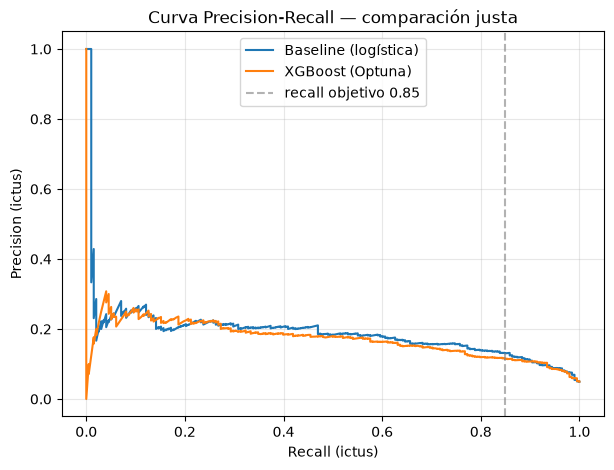

In [24]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

# probabilidades por CV (sin leakage: cada fila predicha por un fold que no la vio)
proba_log = cross_val_predict(modelo_log,     X_train_final, y_train, cv=cv, method="predict_proba")[:, 1]
proba_xgb = cross_val_predict(modelo_xgb_opt, X_train_final, y_train, cv=cv, method="predict_proba")[:, 1]

prec_log, rec_log, _ = precision_recall_curve(y_train, proba_log)
prec_xgb, rec_xgb, _ = precision_recall_curve(y_train, proba_xgb)

plt.figure(figsize=(7, 5))
plt.plot(rec_log, prec_log, label="Baseline (logística)")
plt.plot(rec_xgb, prec_xgb, label="XGBoost (Optuna)")
plt.axvline(0.85, color="gray", linestyle="--", alpha=0.6, label="recall objetivo 0.85")
plt.xlabel("Recall (ictus)")
plt.ylabel("Precision (ictus)")
plt.title("Curva Precision-Recall — comparación justa")
plt.legend()
plt.grid(alpha=0.3)
plt.show()